In [216]:
import numpy as np
import healpy as hp
import treecorr
import matplotlib.pyplot as plt
import matplotlib as mpl
import shutil
from astropy.table import Table
import scipy.integrate
from scipy.interpolate import UnivariateSpline

# ── Plot style (close to your script style) ───────────────────────────────────
fontsi = 18
fontsi2 = 15

if shutil.which("latex") is not None:
    plt.rc("text", usetex=True)
    plt.rcParams["font.serif"] = ["Computer Modern"]

mpl.rcParams.update({
    "figure.dpi": 120,
    "axes.labelsize": fontsi,
    "axes.titlesize": fontsi,
    "xtick.labelsize": fontsi2,
    "ytick.labelsize": fontsi2,
    "legend.fontsize": fontsi2,
    "axes.linewidth": 1.2,
    "grid.alpha": 0.25,
    "grid.linestyle": "--",
    "lines.linewidth": 2.0,
})

def pretty_ax(ax, xlabel=None, ylabel=None, title=None, xlog=False, ylog=False):
    if xlabel is not None:
        ax.set_xlabel(xlabel)
    if ylabel is not None:
        ax.set_ylabel(ylabel)
    if title is not None:
        ax.set_title(title)
    if xlog:
        ax.set_xscale("log")
    if ylog:
        ax.set_yscale("log")
    ax.grid(True)
    ax.tick_params(length=5, width=1.2)

def in_complicated_mask(theta, phi):
    """Survey-like footprint made from two curved longitude bands with a notch cutout."""
    mu = np.cos(theta)
    phi_wrap = np.mod(phi, 2.0 * np.pi)

    band_1 = (
        (phi_wrap >= 0.15 * np.pi) & (phi_wrap <= 0.95 * np.pi) &
        (mu >= -0.25) & (mu <= 0.28)
    )
    band_2 = (
        (phi_wrap >= 1.15 * np.pi) & (phi_wrap <= 1.75 * np.pi) &
        (mu >= -0.35) & (mu <= 0.05)
    )

    # Add curved top boundary to avoid purely rectangular edges.
    curved_cap = mu <= (0.30 * np.sin(2.0 * phi_wrap) - 0.02)

    # Remove an internal notch to make the mask non-trivial.
    notch = (
        (phi_wrap >= 0.45 * np.pi) & (phi_wrap <= 0.62 * np.pi) &
        (mu >= -0.02) & (mu <= 0.20)
    )

    return (band_1 | band_2) & curved_cap & (~notch)

def sample_positions_in_mask(n_obj, rng, masking=True):
    """Draw exactly n_obj points uniformly on the sphere, then keep only masked points."""
    if not masking:
        phi = rng.uniform(0.0, 2.0 * np.pi, n_obj)
        mu = rng.uniform(-1.0, 1.0, n_obj)
        return np.arccos(mu), phi

    theta_chunks = []
    phi_chunks = []
    kept = 0

    while kept < n_obj:
        # Overdraw by a factor to keep rejection sampling efficient.
        n_draw = max(20000, int(3.0 * (n_obj - kept)))
        phi_try = rng.uniform(0.0, 2.0 * np.pi, n_draw)
        mu_try = rng.uniform(-1.0, 1.0, n_draw)
        theta_try = np.arccos(mu_try)
        keep = in_complicated_mask(theta_try, phi_try)

        if np.any(keep):
            theta_chunks.append(theta_try[keep])
            phi_chunks.append(phi_try[keep])
            kept += np.sum(keep)

    theta = np.concatenate(theta_chunks)[:n_obj]
    phi = np.concatenate(phi_chunks)[:n_obj]
    return theta, phi

# ══════════════════════════════════════════════════════════════════════════════
# 1.  SHEAR POWER SPECTRA  (pure E-mode, as expected for weak lensing at tree level)
# ══════════════════════════════════════════════════════════════════════════════
NSIDE  = 1024
LMAX   = 3 * NSIDE - 1
ell    = np.arange(LMAX + 1)

# Weak-lensing-like EE spectrum:  C_ℓ ∝ ℓ⁻²  (you can swap in a CLASS/CAMB output)
cl_EE = np.zeros(LMAX + 1)
cl_BB = np.zeros(LMAX + 1)   # set > 0 to add B-modes (e.g. PSF residuals, IAs)
cl_EB = np.zeros(LMAX + 1)   # non-zero only for cosmic birefringence studies
cl_TT = np.zeros(LMAX + 1)
cl_TE = np.zeros(LMAX + 1)
cl_TB = np.zeros(LMAX + 1)

cls_data = np.loadtxt("cls.txt")
ell_data = cls_data[:, 0]
cl_EE_data = cls_data[:, 1]

ell_pivot = 200
mask = ell >= 2
cl_EE = np.interp(ell, ell_data, cl_EE_data)  # use data for EE spectrum

#1e-7 * (ell[mask] / ell_pivot) ** (-1.5)   # adjust amplitude & slope freely

In [217]:
from pathlib import Path
import re
import numpy as np

base = Path('/Users/robert/Documents/Git/cosebis_benchmark/benchmarks_cosebis')

def load_tpm_modes(pattern):
    files = sorted(base.glob(pattern))
    if not files:
        raise FileNotFoundError(f'No files matched {pattern}')
    theta_ref = None
    modes = []
    mode_numbers = []
    for fp in files:
        arr = np.loadtxt(fp, comments='#')
        if arr.ndim != 2 or arr.shape[1] < 2:
            raise ValueError(f'Unexpected format in {fp.name}: expected >=2 columns')
        theta, vals = arr[:, 0], arr[:, 1]
        if theta_ref is None:
            theta_ref = theta
        elif not np.allclose(theta, theta_ref, rtol=1e-10, atol=0.0):
            raise ValueError(f'Theta grid mismatch in {fp.name}')
        modes.append(vals)
        m = re.search(r'mode_(\d+)\.txt$', fp.name)
        mode_numbers.append(int(m.group(1)) if m else -1)
    return theta_ref, np.asarray(modes), np.asarray(mode_numbers)

theta_arcmin, tm_modes, tm_mode_numbers = load_tpm_modes('Tm_benchmark_2.0_300.0_mode_*.txt')
_,            tp_modes, tp_mode_numbers = load_tpm_modes('Tp_benchmark_2.0_300.0_mode_*.txt')

print(f'Tm: {tm_modes.shape}  modes {tm_mode_numbers}')
print(f'Tp: {tp_modes.shape}  modes {tp_mode_numbers}')

Tm: (20, 10000)  modes [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20]
Tp: (20, 10000)  modes [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20]


/var/folders/4k/46233y0d3tx9bcbm7l78j0mr0000gn/T/ipykernel_5761/3902189824.py:24: HealpyDeprecationWarning: "verbose" was deprecated in version 1.15.0 and will be removed in a future version. 
  _, Q_map, U_map = hp.synfast(


0


/var/folders/4k/46233y0d3tx9bcbm7l78j0mr0000gn/T/ipykernel_5761/3902189824.py:136: RuntimeWarning: divide by zero encountered in log
  spline = UnivariateSpline(np.log(ell), np.log(cl_EE), s=0, k=1, ext=0)


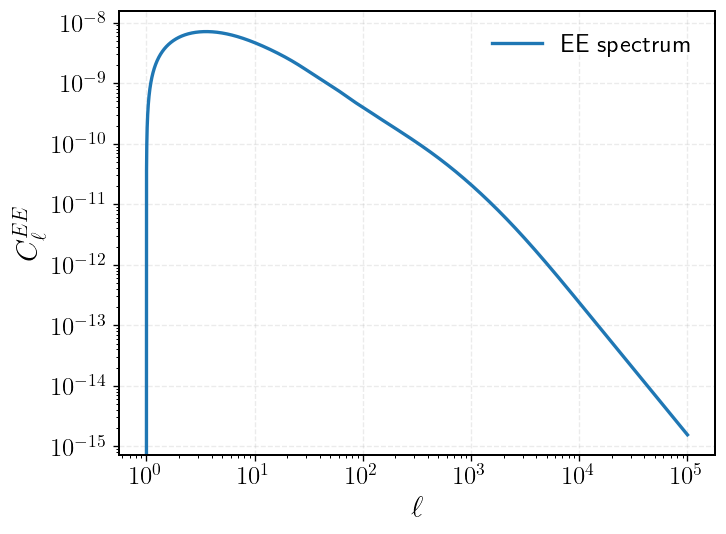

/var/folders/4k/46233y0d3tx9bcbm7l78j0mr0000gn/T/ipykernel_5761/3902189824.py:160: RuntimeWarning: invalid value encountered in sqrt
  analytic_xip_err = np.sqrt(var_xip_shape)


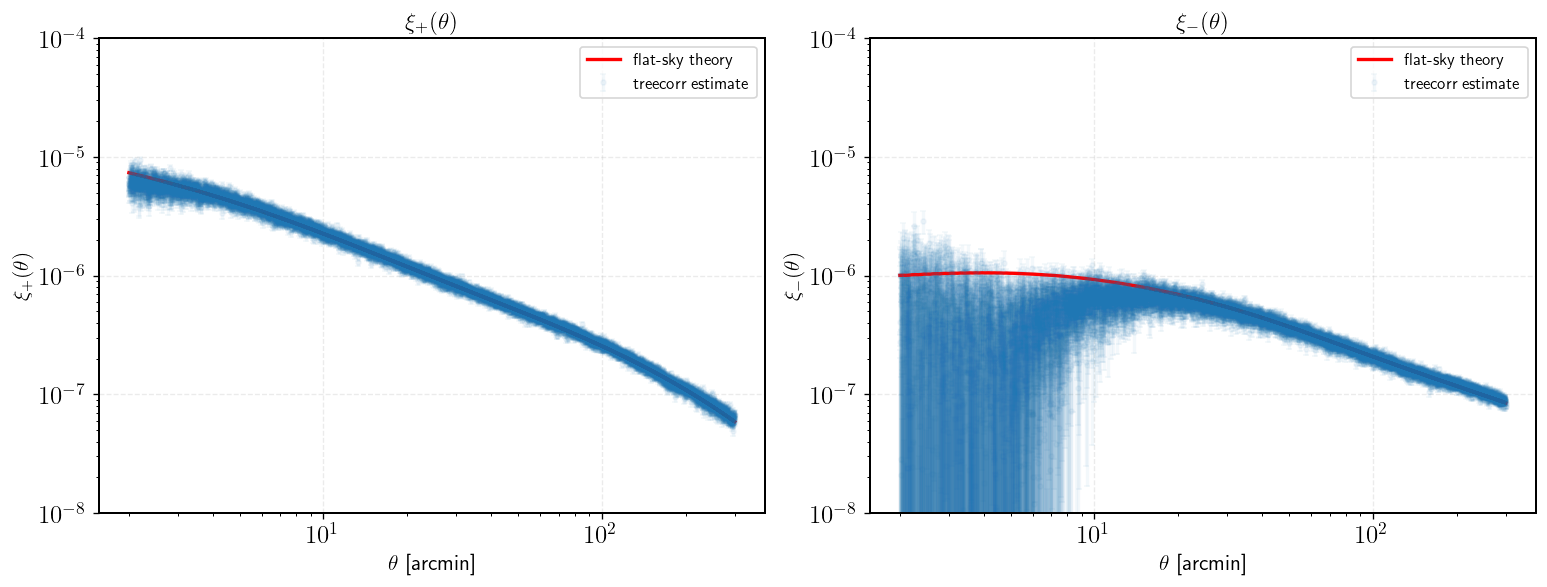

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99


In [222]:
from scipy.interpolate import interp1d
from scipy.integrate import simpson


Bn_list = []
En_list = []
En_shape_cov_list = []
Bn_shape_cov_list = []
shape_var_xip_list = []
shape_var_xim_list = []
pair_counts_treecorr = None
dNpair_dtheta_arcmin = None

arcmin_to_rad = np.pi / 180.0 / 60.0
masking = False
i_sample = 0
nsims = 100
np.random.seed(42)
while i_sample < nsims:
    # Keep a copy of the COSEBIs theta grid before treecorr overwrites theta_arcmin.
    theta_filter_arcmin = np.array(theta_arcmin, copy=True)

    # ── synfast: [TT, EE, BB, TE, EB, TB]  (new=True ordering) ───────────────────
    _, Q_map, U_map = hp.synfast(
        [cl_TT, cl_EE, cl_BB, cl_TE, cl_EB, cl_TB],
        nside=NSIDE, lmax=LMAX, new=True, pol=True, verbose=False,
    )

    print(i_sample)
    # ══════════════════════════════════════════════════════════════════════════════
    # 2.  BUILD A RANDOM CATALOGUE BY SAMPLING THE SHEAR MAPS
    # ══════════════════════════════════════════════════════════════════════════════
    N_GAL = 1_000_000

    rng = np.random.default_rng(0)

    if i_sample == 0:
        theta, phi = sample_positions_in_mask(N_GAL, rng, masking=masking)

    g1 = hp.get_interp_val(Q_map, theta, phi)
    g2 = hp.get_interp_val(U_map, theta, phi)

    ra_deg = np.degrees(phi)
    dec_deg = 90.0 - np.degrees(theta)

    sigma_e = 0.0
    if sigma_e > 0.0:
        g1 += rng.normal(0, sigma_e, N_GAL)
        g2 += rng.normal(0, sigma_e, N_GAL)

    w = np.ones(N_GAL)

    cat_table = Table({
        "ra": ra_deg,
        "dec": dec_deg,
        "g1": g1,
        "g2": g2,
        "w": w,
    })

    # ══════════════════════════════════════════════════════════════════════════════
    # 3.  TREECORR  ─  measure ξ₊ and ξ₋
    # ══════════════════════════════════════════════════════════════════════════════
    tc_cat = treecorr.Catalog(
        ra=ra_deg, dec=dec_deg,
        g1=g1, g2=-g2,
        w=w,
        ra_units="degrees", dec_units="degrees",
    )

    gg = treecorr.GGCorrelation(
        min_sep=theta_filter_arcmin[0],
        max_sep=theta_filter_arcmin[-1],
        nbins=len(theta_filter_arcmin),
        sep_units="arcmin",
        bin_slop=0.,
        verbose=1,
    )

    gg.process(tc_cat)

    # ── Results ───────────────────────────────────────────────────────────────────
    theta_arcmin = np.exp(gg.meanlogr)
    xip = gg.xip
    xim = gg.xim
    xip_err = np.sqrt(gg.varxip)
    xim_err = np.sqrt(gg.varxim)

    # Effective per-component ellipticity variance entering the shape-noise term.
    sigma2_eps = 0.5 * np.mean(g1**2 + g2**2)

    th = theta_arcmin
    th_tc = np.exp(gg.meanlogr)

    f_xip = interp1d(th_tc, gg.xip, kind='cubic', bounds_error=False, fill_value=0.0)
    f_xim = interp1d(th_tc, gg.xim, kind='cubic', bounds_error=False, fill_value=0.0)

    xip_fine = f_xip(th)
    xim_fine = f_xim(th)

    E_n = np.array([
        0.5 * simpson(th * (tp * xip_fine + tm * xim_fine), x=th)
        for tp, tm in zip(tp_modes, tm_modes)
    ])

    B_n = np.array([
        0.5 * simpson(th * (tp * xip_fine - tm * xim_fine), x=th)
        for tp, tm in zip(tp_modes, tm_modes)
    ])

    # Shape-noise covariance from TreeCorr's actual pair counts in each theta bin.
    dtheta_arcmin = np.gradient(th)
    pair_counts_treecorr = gg.npairs
    dNpair_dtheta_arcmin = np.gradient(pair_counts_treecorr) / dtheta_arcmin
    dnpair_real = (pair_counts_treecorr[1:] + pair_counts_treecorr[:-1]) / 2.0 / (th[1:] - th[:-1])

    spline_real = UnivariateSpline(th[1:], dnpair_real, s=0)

    var_xip_shape = sigma2_eps**2 / spline_real(th)
    Tpm_product = tp_modes[:, None, :] * tp_modes[None, :, :] + tm_modes[:, None, :] * tm_modes[None, :, :]
    cosebi_sn = 0.5 * simpson(th**2 * var_xip_shape[None, None, :] * Tpm_product, x=th, axis=-1)
    En_list.append(E_n)
    Bn_list.append(B_n)

    if i_sample == 0:
        # ══════════════════════════════════════════════════════════════════════════════
        # 4.  COMPARE WITH THEORETICAL PREDICTION  (flat-sky)
        # ══════════════════════════════════════════════════════════════════════════════
        def xi_pm_theory_flatsky(theta_rad, cl_EE, cl_BB, ell):
            """
            Flat-sky shear two-point functions via Hankel transforms.
            """
            from scipy.special import j0, jv

            ell_cut = np.geomspace(1, 1e5, int(1e5))
            spline = UnivariateSpline(np.log(ell), np.log(cl_EE), s=0, k=1, ext=0)
            EE = np.exp(spline(np.log(ell_cut)))
            x = np.outer(ell_cut, theta_rad)

            plt.loglog(ell_cut, EE, label='EE spectrum')
            plt.xlabel(r'$\ell$')
            plt.ylabel(r'$C_\ell^{EE}$')
            #plt.title('Input EE power spectrum')
            plt.grid(True, alpha=0.25)
            plt.legend(frameon=False)
            #plt.savefig('cl_EE.png', dpi=150, bbox_inches='tight')
            plt.show()
            xip_th = 1 / 2 / np.pi * scipy.integrate.simpson(
                (ell_cut * EE)[:, None] * j0(x), x=ell_cut, axis=0
            )
            xim_th = 1 / 2 / np.pi * scipy.integrate.simpson(
                (ell_cut * EE)[:, None] * jv(4, x), x=ell_cut, axis=0
            )

            return xip_th, xim_th

        theta_rad_fine = np.geomspace(theta_filter_arcmin[0], theta_filter_arcmin[-1], 200) * arcmin_to_rad
        xip_th, xim_th = xi_pm_theory_flatsky(theta_rad_fine, cl_EE_data, cl_BB, ell_data)
        theta_fine_arcmin = theta_rad_fine / arcmin_to_rad
        analytic_xip_err = np.sqrt(var_xip_shape)

        fig, axes = plt.subplots(1, 2, figsize=(13, 5))
        for ax, xi_data, xi_err_data, xi_theory, xi_shape_err, label in zip(
            axes,
            [xip, xim],
            [xip_err, xim_err],
            [xip_th, xim_th],
            [analytic_xip_err, analytic_xip_err],
            [r'$\xi_+(\theta)$', r'$\xi_-(\theta)$'],
        ):
            ax.errorbar(theta_arcmin, xi_data, yerr=xi_err_data,
                        fmt='o', ms=3, capsize=2, label='treecorr estimate', alpha=.05)
            """ax.errorbar(theta_arcmin, xi_data, yerr=xi_shape_err,
                        fmt='o', ms=3, capsize=2, label='treecorr estimate', alpha=.05)"""
            ax.plot(theta_fine_arcmin, xi_theory, label='flat-sky theory', color='red')
            ax.axhline(0, color='grey', lw=0.8, ls='--')
            ax.set_xlabel(r'$\theta$ [arcmin]', fontsize=13)
            ax.set_xscale('log')
            ax.set_yscale('log')
            ax.set_ylim(1e-8, 1e-4)
            ax.set_ylabel(label, fontsize=13)
            #ax.set_title(label, fontsize=14)
            ax.legend(fontsize=10)
            ax.grid(True, alpha=0.25)

        #plt.suptitle('Shear two-point functions — flat-sky theory vs treecorr', fontsize=14, y=1.02)
        plt.tight_layout()
        plt.savefig('xi_pm.png', dpi=150, bbox_inches='tight')
        plt.show()
    i_sample += 1

In [223]:
# Effective survey area for the footprint
# For the complicated mask we compute area numerically using a dense random sphere sample.

rng_area = np.random.default_rng(123)
n_area = 2_000_000
phi_try = rng_area.uniform(0.0, 2.0 * np.pi, n_area)
mu_try = rng_area.uniform(-1.0, 1.0, n_area)
theta_try = np.arccos(mu_try)

if masking:
    keep = in_complicated_mask(theta_try, phi_try)
    mask_name = 'complicated mask'
else:
    keep = np.ones_like(theta_try, dtype=bool)
    mask_name = 'full-sky mask'

f_sky_mc = np.mean(keep)
area_sr_mc = f_sky_mc * 4.0 * np.pi
area_deg2_mc = area_sr_mc * (180.0 / np.pi) ** 2

theta_eq_rad = np.sqrt(area_sr_mc / np.pi)
theta_eq_deg = np.degrees(theta_eq_rad)

print(f'Footprint: {mask_name}')
print(f'  Monte Carlo f_sky = {f_sky_mc:.6f}')
print(f'  Monte Carlo area  = {area_sr_mc:.6f} sr')
print(f'  Monte Carlo area  = {area_deg2_mc:.2f} deg^2')
print(f'  equivalent circular radius = {theta_eq_deg:.2f} deg')

Footprint: full-sky mask
  Monte Carlo f_sky = 1.000000
  Monte Carlo area  = 12.566371 sr
  Monte Carlo area  = 41252.96 deg^2
  equivalent circular radius = 114.59 deg


Pixelized f_sky = 1.000000
Pixelized area  = 41252.96 deg^2


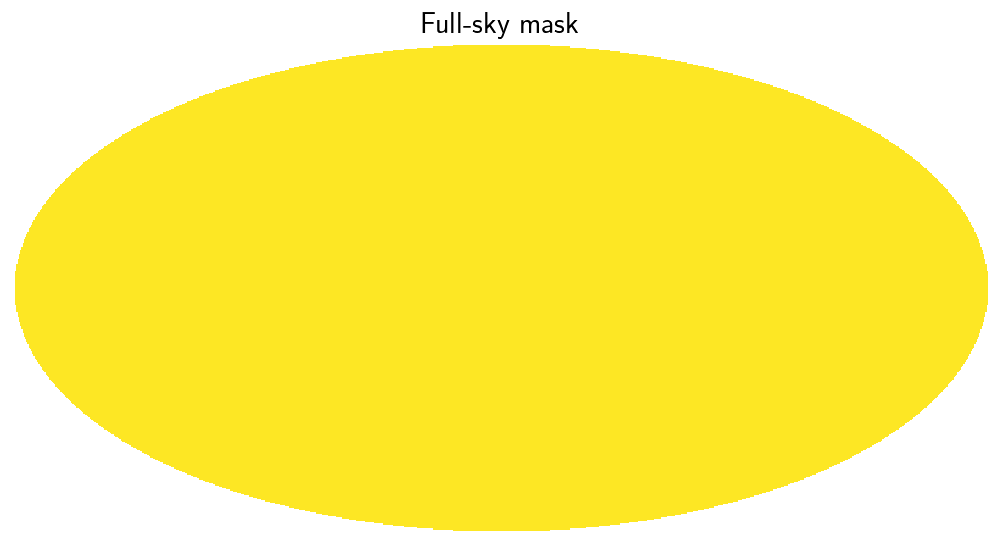

In [224]:
# Visualize the survey footprint on the sphere
# Uses the same mask function as the simulation sampling.

plot_nside = 256
npix_plot = hp.nside2npix(plot_nside)
theta_pix, phi_pix = hp.pix2ang(plot_nside, np.arange(npix_plot))

if masking:
    footprint_map = in_complicated_mask(theta_pix, phi_pix).astype(float)
else:
    footprint_map = np.ones(npix_plot)

fsky_pix = np.mean(footprint_map)
area_deg2_pix = fsky_pix * 4.0 * np.pi * (180.0 / np.pi) ** 2

print(f'Pixelized f_sky = {fsky_pix:.6f}')
print(f'Pixelized area  = {area_deg2_pix:.2f} deg^2')

hp.mollview(
    footprint_map,
    title=r'Complicated footprint mask' if masking else r'Full-sky mask',
    cmap='viridis',
    min=0.0,
    max=1.0,
    cbar=False,
)
plt.savefig('footprint_mask_mollview.png', dpi=180, bbox_inches='tight')
plt.show()

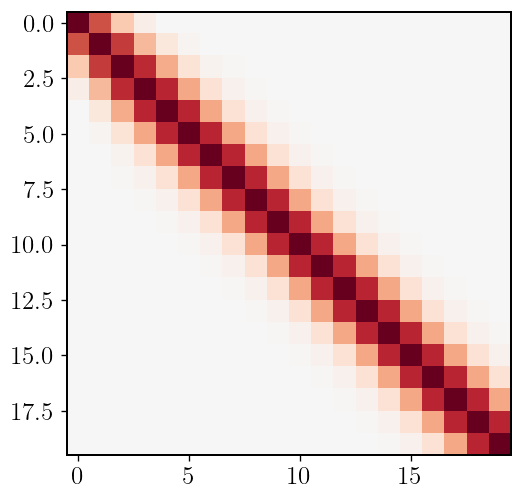

In [225]:
corr_cosebisn = cosebi_sn/ np.outer(np.sqrt(np.diag(cosebi_sn)), np.sqrt(np.diag(cosebi_sn)))
#print(corr_cosebisn)
plt.imshow(corr_cosebisn, vmin=-1, vmax=1, cmap='RdBu_r')

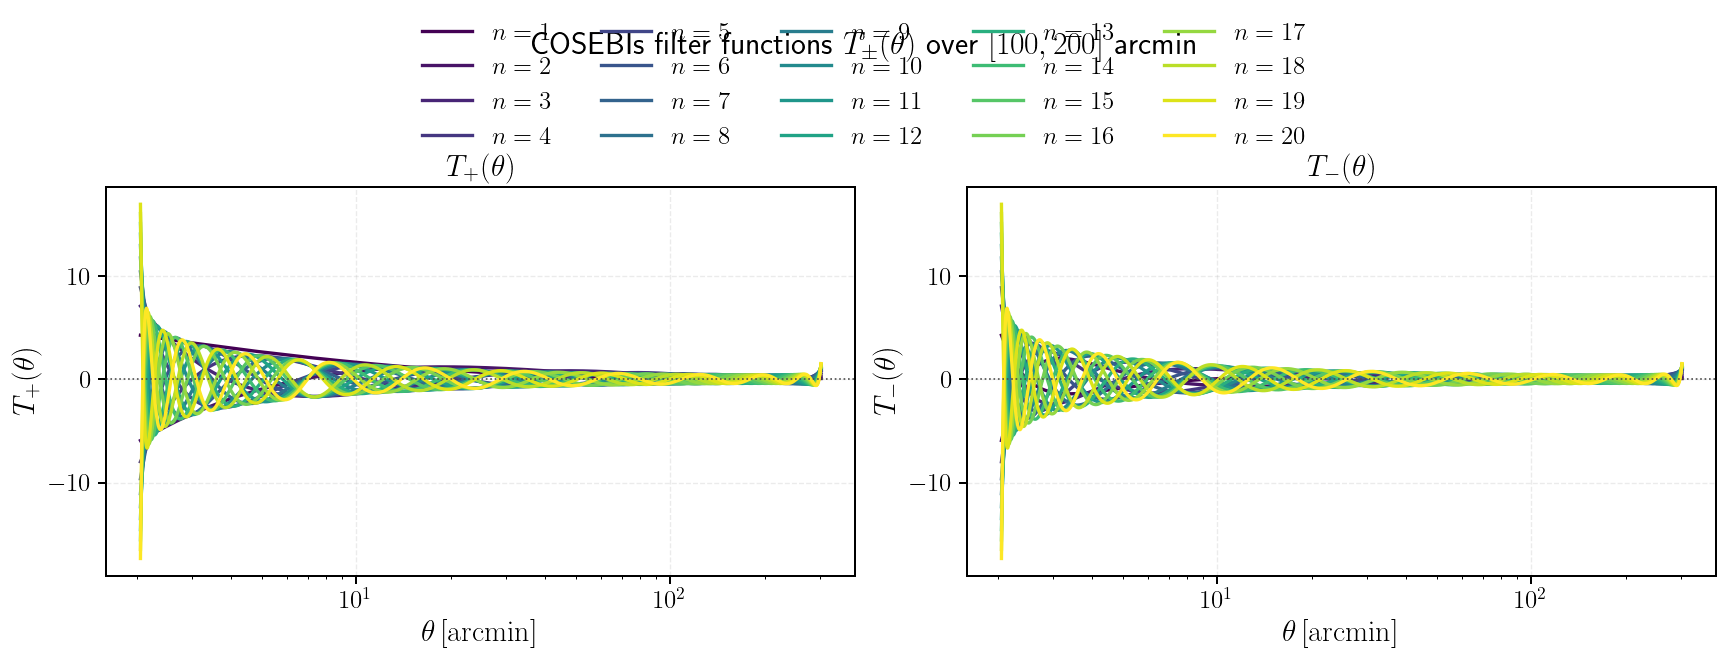

In [226]:
cmap_modes = plt.get_cmap('viridis')
n_modes = tm_modes.shape[0]
colors = [cmap_modes(i / (n_modes - 1)) for i in range(n_modes)]

fig, axes = plt.subplots(1, 2, figsize=(14.5, 5.2), sharex=True)

for i, (tp, tm, n) in enumerate(zip(tp_modes, tm_modes, tp_mode_numbers)):
    axes[0].plot(theta_arcmin, tp, color=colors[i], lw=2.0, label=rf'$n={n}$')
    axes[1].plot(theta_arcmin, tm, color=colors[i], lw=2.0, label=rf'$n={n}$')

for ax, title in zip(axes, [r'$T_+(\theta)$', r'$T_-(\theta)$']):
    ax.axhline(0, color='0.3', lw=1.0, ls=':')
    pretty_ax(ax, xlabel=r'$\theta\,[\mathrm{arcmin}]$', ylabel=title, title=title, xlog=True)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, ncol=5, frameon=False, loc='upper center', bbox_to_anchor=(0.5, 1.07))

plt.suptitle(r'COSEBIs filter functions $T_\pm(\theta)$ over $[100,200]$ arcmin', fontsize=fontsi+1, y=1.02)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig('Tpm_modes_100_200.png', dpi=180, bbox_inches='tight')
plt.show()

Mode   E_n             B_n
   1   +9.053290e-04   +4.283212e-06
   2   +8.352937e-04   +3.627198e-06
   3   +5.244348e-04   +2.442583e-06
   4   +3.515978e-04   +2.389265e-06
   5   +1.952107e-04   -2.522549e-07
   6   +9.512050e-05   -2.715452e-06
   7   +4.467469e-05   -2.232309e-06
   8   +1.899089e-05   -1.360677e-06
   9   +1.105938e-05   +6.984889e-07
  10   +6.666053e-06   -4.660145e-08
  11   +5.349176e-06   -3.846796e-07
  12   +5.386167e-06   -6.897924e-07
  13   +3.217511e-06   -6.369890e-07
  14   +2.552483e-06   +4.980647e-07
  15   -1.795052e-06   +5.096099e-07
  16   -6.965785e-06   -1.993243e-06
  17   -6.764179e-06   -3.718319e-06
  18   -5.162962e-06   -1.540436e-06
  19   -5.157299e-06   +4.130365e-07
  20   +2.190408e-07   +3.050469e-08


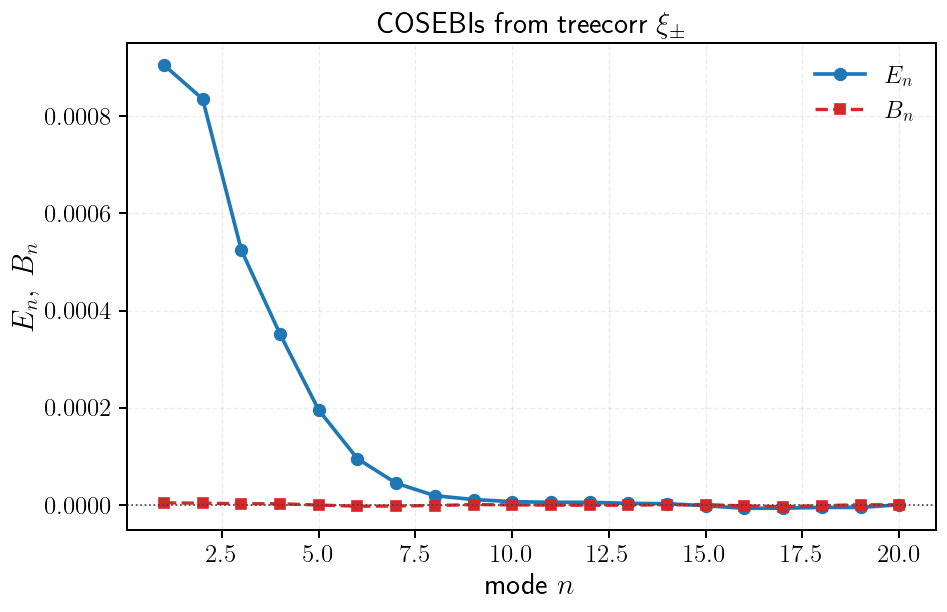

In [227]:
# Compute COSEBIs E_n and B_n from treecorr ξ± using the T± filter functions
modes = tp_mode_numbers
print("Mode   E_n             B_n")
for n, e, b in zip(modes, E_n, B_n):
    print(f"  {n:2d}   {e:+.6e}   {b:+.6e}")

fig, ax = plt.subplots(figsize=(8, 5.2))
ax.plot(modes, E_n, 'o-', color='#1f77b4', ms=7, lw=2.2, label=r'$E_n$')
ax.plot(modes, B_n, 's--', color='#d62728', ms=6, lw=2.0, label=r'$B_n$')
ax.axhline(0, color='0.25', lw=1.0, ls=':')
pretty_ax(ax, xlabel=r'mode $n$', ylabel=r'$E_n,\;B_n$', title=r'COSEBIs from treecorr $\xi_\pm$')
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig('cosebis_En_Bn.png', dpi=180, bbox_inches='tight')
plt.show()

(100, 20) (100, 20)


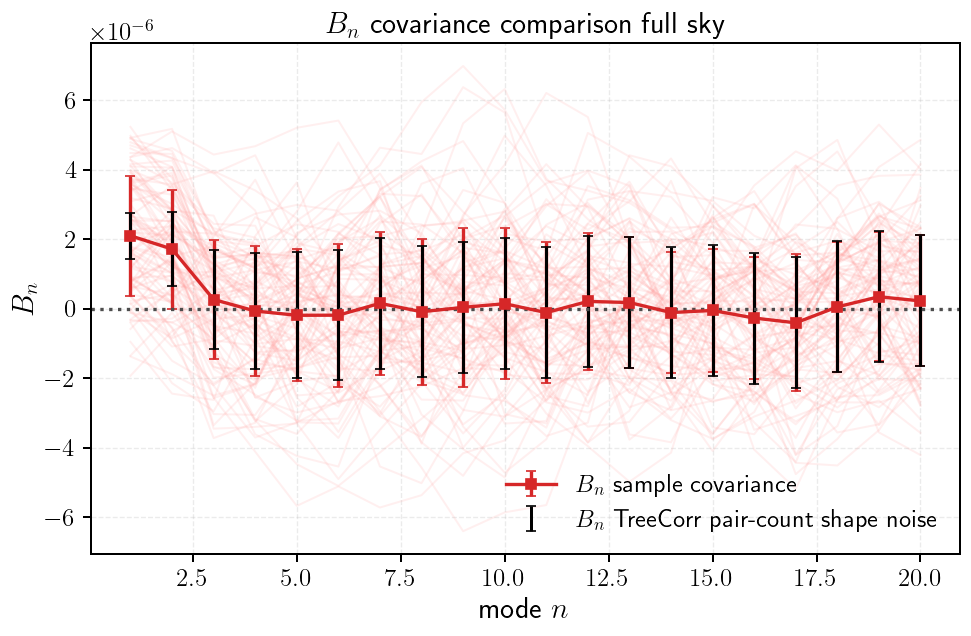

SNR_E (MC)                    = 199.95
SNR_B (MC)                    = 1.83
SNR_E (TreeCorr pair counts)  = 1361.92
SNR_B (TreeCorr pair counts)  = 1.27


In [228]:
En_list = np.array(En_list)
Bn_list = np.array(Bn_list)

print(En_list.shape, Bn_list.shape)
En_cov = np.cov(En_list, rowvar=False)
Bn_cov = np.cov(Bn_list, rowvar=False)

modes = np.arange(1, En_cov.shape[0] + 1)
err_En_mc = np.sqrt(np.diag(En_cov))
err_Bn_mc = np.sqrt(np.diag(Bn_cov))
err_En_shape = np.sqrt(np.diag(cosebi_sn))
err_Bn_shape = np.sqrt(np.diag(cosebi_sn))

fig, ax = plt.subplots(figsize=(8.2, 5.4))
for B in Bn_list:
    ax.plot(modes, B, color='#ff9896', lw=1.2, alpha=0.15)

ax.errorbar(modes, Bn_list.mean(axis=0), yerr=err_Bn_mc, fmt='s-', color='#d62728',
            capsize=3, lw=2.0, ms=6, label=r'$B_n$ sample covariance')
ax.errorbar(modes, Bn_list.mean(axis=0), yerr=err_Bn_shape, fmt='none',
            ecolor='black', capsize=3, lw=1.8, label=r'$B_n$ TreeCorr pair-count shape noise')
ax.axhline(0, color='0.3', ls=':')
if not masking:
    pretty_ax(ax, xlabel=r'mode $n$', ylabel=r'$B_n$', title=r'$B_n$ covariance comparison full sky')
else:
    pretty_ax(ax, xlabel=r'mode $n$', ylabel=r'$B_n$', title=r'$B_n$ covariance comparison masked')
ax.legend(frameon=False, loc='lower right')
plt.tight_layout()
if not masking:
    plt.savefig('cosebis_shape_noise_comparison_many_n.png', dpi=180, bbox_inches='tight')
plt.show()

SNR_E = np.sqrt(En_list.mean(axis=0) @ np.linalg.pinv(En_cov) @ En_list.mean(axis=0))
SNR_B = np.sqrt(Bn_list.mean(axis=0) @ np.linalg.pinv(Bn_cov) @ Bn_list.mean(axis=0))
SNR_E_shape = np.sqrt(En_list.mean(axis=0) @ np.linalg.pinv(cosebi_sn) @ En_list.mean(axis=0))
SNR_B_shape = np.sqrt(Bn_list[0] @ np.linalg.pinv(cosebi_sn) @ Bn_list[0]/len(Bn_list[0]))
print(f'SNR_E (MC)                    = {SNR_E:.2f}')
print(f'SNR_B (MC)                    = {SNR_B:.2f}')
print(f'SNR_E (TreeCorr pair counts)  = {SNR_E_shape:.2f}')
print(f'SNR_B (TreeCorr pair counts)  = {SNR_B_shape:.2f}')

/var/folders/4k/46233y0d3tx9bcbm7l78j0mr0000gn/T/ipykernel_5761/4011934188.py:13: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


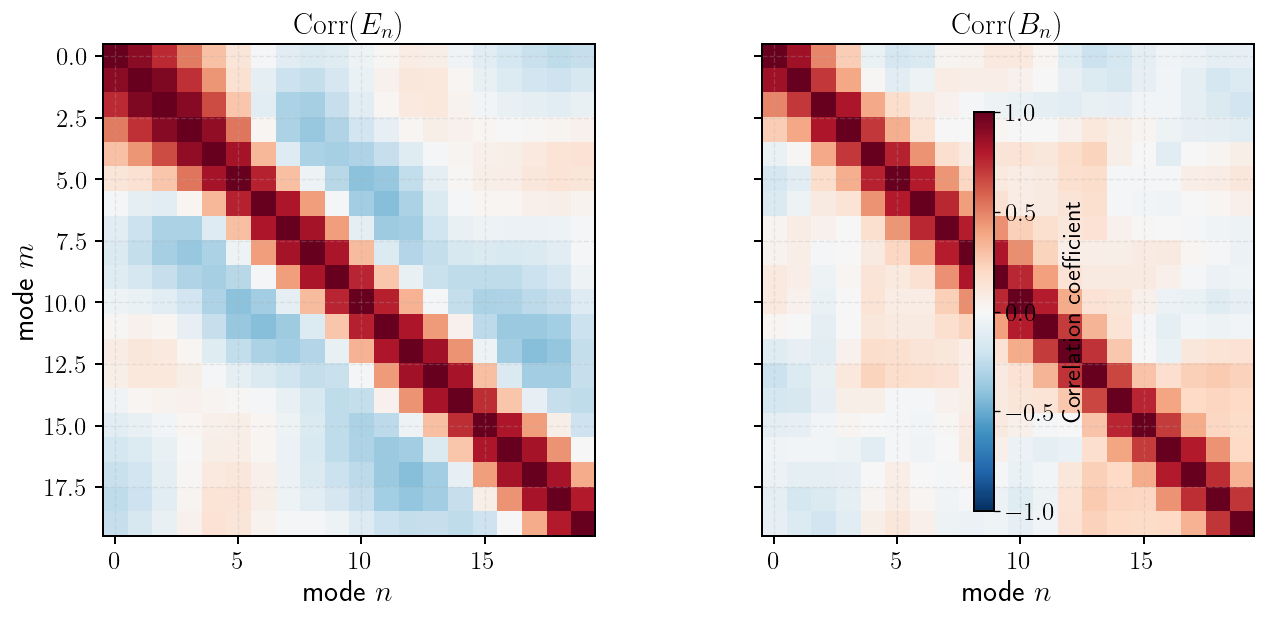

In [229]:
corr_E = En_cov / np.outer(np.sqrt(np.diag(En_cov)), np.sqrt(np.diag(En_cov)))
corr_B = Bn_cov / np.outer(np.sqrt(np.diag(Bn_cov)), np.sqrt(np.diag(Bn_cov)))

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.8), sharex=True, sharey=True)
im0 = axes[0].imshow(corr_E, vmin=-1, vmax=1, cmap='RdBu_r')
im1 = axes[1].imshow(corr_B, vmin=-1, vmax=1, cmap='RdBu_r')

pretty_ax(axes[0], xlabel=r'mode $n$', ylabel=r'mode $m$', title=r'$\mathrm{Corr}(E_n)$')
pretty_ax(axes[1], xlabel=r'mode $n$', ylabel=None, title=r'$\mathrm{Corr}(B_n)$')

cbar = fig.colorbar(im1, ax=axes.ravel().tolist(), shrink=0.9)
cbar.set_label('Correlation coefficient', fontsize=fontsi2)
plt.tight_layout()
plt.savefig('cosebis_En_cov.png', dpi=180, bbox_inches='tight')
plt.show()

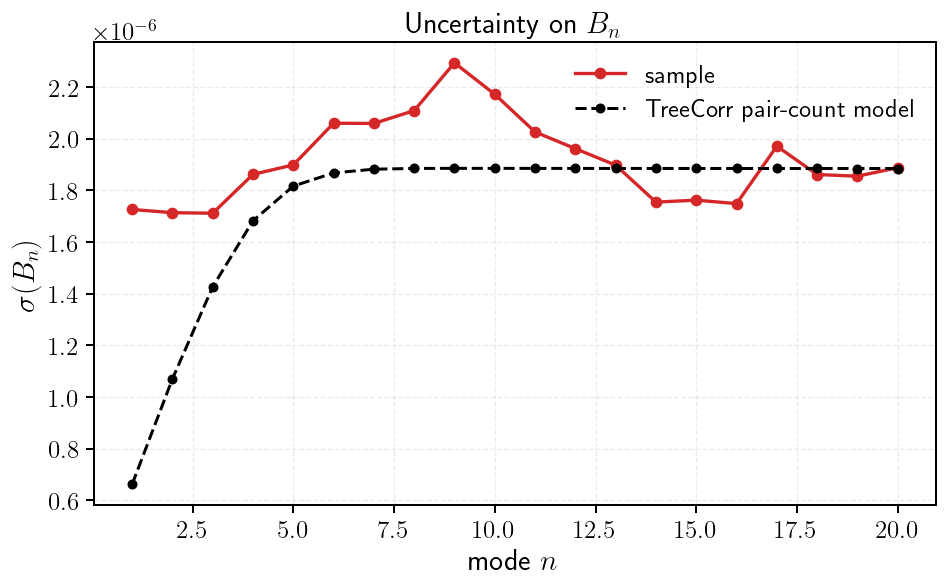

In [230]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(modes, np.sqrt(np.diag(Bn_cov)), 'o-', color='#d62728', ms=6, lw=2.0, label='sample')
ax.plot(modes, np.sqrt(np.diag(cosebi_sn)), 'o--', color='black', ms=5, lw=1.8, label='TreeCorr pair-count model')
pretty_ax(ax, xlabel=r'mode $n$', ylabel=r'$\sigma(B_n)$', title=r'Uncertainty on $B_n$')
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig('cosebis_Bn_uncertainty_comparison.png', dpi=180, bbox_inches='tight')
plt.show()